In [ ]:
import os

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)  
pd.set_option('display.max_colwidth', None) 

In [ ]:
import albumentations as A

In [ ]:
from pathlib import Path

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
sns.set_style('darkgrid')

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from tensorflow.keras import Sequential, Input, Model

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Dropout

In [ ]:
import cv2

In [ ]:
from PIL import ImageFile

In [ ]:
def walk_through_dir(filepath):
    for dirpath, dirnames, filenames in os.walk(filepath):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
    print()

In [ ]:
def get_filetypes(filepath):
    exts = set(os.path.splitext(f)[1] for dir,dirs,files in os.walk(filepath) for f in files)
    print("File extentions on image directory: ", exts)
    return exts

In [2]:
def process_img(filepath):
    filenames = list(Path(filepath).glob(r'**/*{}'.format('jpg')))
    labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filenames))
    
    filepaths = pd.Series(filenames, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')

    image_df = pd.concat([filepaths, labels], axis=1)
    return image_df.sample(frac=1)

In [ ]:
file_exts = get_filetypes("Dataset/train")

In [ ]:
train_path = "Dataset/train"

In [ ]:
test_path = "Dataset/test"

In [ ]:
val_path = "Dataset/valid"

In [ ]:
train_df = process_img(train_path)

In [ ]:
val_df = process_img(val_path)

In [ ]:
test_df = process_img(test_path)

In [ ]:
walk_through_dir("Dataset")

In [ ]:
img = cv2.imread(train_df.iloc[0].Filepath)
INPUT_SHAPE = img.shape
print(INPUT_SHAPE)

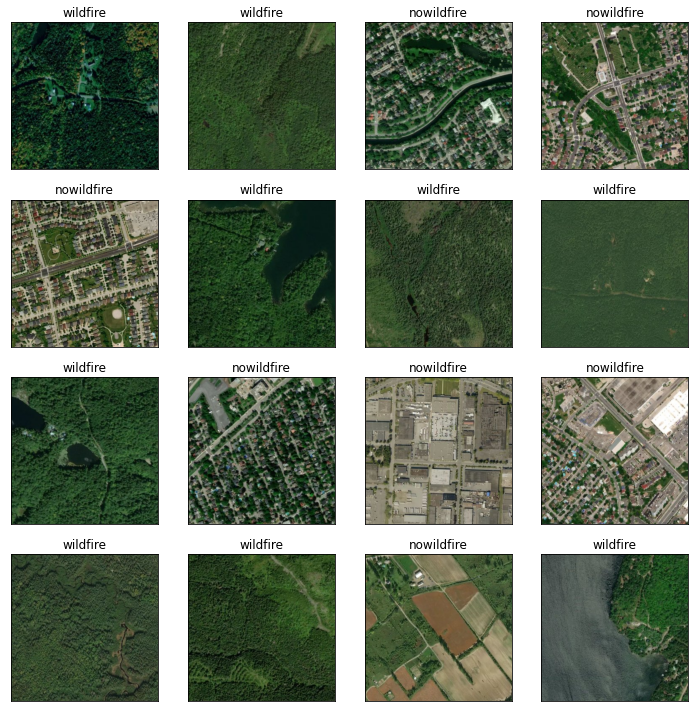

In [5]:
def show_image_sample(df):
    random_data = df.sample(n=16)
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

    for i, ax in enumerate(axes.flat):
        ax.imshow(plt.imread(random_data.iloc[i].Filepath))
        ax.set_title(random_data.iloc[i].Label)
    plt.tight_layout()
    plt.show()
    
show_image_sample(train_df)

In [ ]:
def augment_image(image):
    aug = A.Compose([
        A.Flip(),
        A.Rotate(limit=75,always_apply=True),
    ])
    augmented_image = aug(image=image)['image']
    return augmented_image

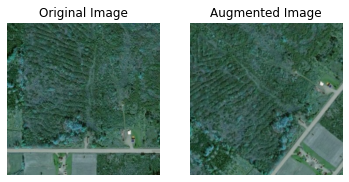

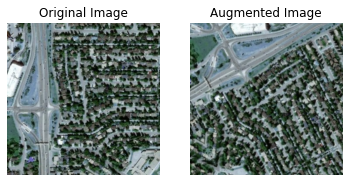

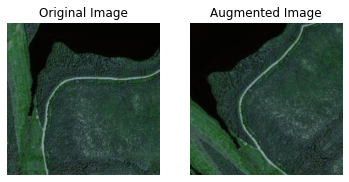

In [6]:
def show_original_augment_image(df):
    random_data = df.sample(n=3)
    for i in range(len(random_data)):
        image = cv2.imread(random_data.iloc[i].Filepath)
        augmented_image = augment_image(image)

        plt.subplot(1,2,1)
        plt.imshow(image)
        plt.axis('off')
        plt.title("Original Image")

        plt.subplot(1,2,2)
        plt.imshow(augmented_image)
        plt.title("Augmented Image")
        plt.axis('off')
        plt.show()

show_original_augment_image(train_df)

In [ ]:
BATCH_SIZE = 256

In [ ]:
train_datagen = ImageDataGenerator(dtype='float32', rescale= 1./255., preprocessing_function=augment_image)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    x_col='Filepath',
                                                    y_col='Label',
                                                    shuffle=True,
                                                    batch_size = BATCH_SIZE,
                                                    target_size = (350,350),
                                                    class_mode = 'categorical')

In [ ]:
val_datagen = ImageDataGenerator(dtype='float32', rescale= 1./255.)

In [ ]:
val_generator = val_datagen.flow_from_dataframe(val_df,
                                                    x_col='Filepath',
                                                    y_col='Label',
                                                    shuffle=True,
                                                    batch_size = BATCH_SIZE,
                                                    target_size = (350,350),
                                                    class_mode = 'categorical')

In [ ]:
test_datagen = ImageDataGenerator(dtype='float32', rescale= 1./255.)

In [ ]:
test_generator = test_datagen.flow_from_dataframe(test_df,
                                                    x_col='Filepath',
                                                    y_col='Label',
                                                    shuffle=False,
                                                    batch_size = BATCH_SIZE,
                                                    target_size = (350,350),
                                                    class_mode = 'categorical')

In [8]:
def create_ensemble_learning_model():
    inputs = Input(shape=(350, 350, 3))
    x = Conv2D(filters = 8, kernel_size=2)(inputs)
    x = MaxPooling2D()(x)

    x = Conv2D(filters = 16, kernel_size=2)(x)
    x = MaxPooling2D()(x)

    x = Conv2D(filters = 32, kernel_size=2)(x)
    x = MaxPooling2D()(x)

    x = Flatten()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(.3)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(.3)(x)

    outputs = Dense(2, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [ ]:
model = create_ensemble_learning_model()

In [9]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 350, 350, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 349, 349, 8)       104       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 174, 174, 8)       0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 173, 173, 16)      528       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 86, 86, 16)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 85, 85, 32)        2080      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 42, 42, 32)        0     

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
model.compile(
        optimizer= 'adam',
        loss='categorical_crossentropy',
        metrics=['accuracy', 'AUC']
    )

In [ ]:
checkpoint = ModelCheckpoint('model.hdf5',verbose=1, save_best_only= True)

In [ ]:
early_stopping = EarlyStopping(monitor= 'val_loss', patience= 10)

In [ ]:
history = model.fit(train_generator,
                        epochs = 10,
                        verbose = 1,
                        validation_data = val_generator,
                        callbacks = [checkpoint, early_stopping])

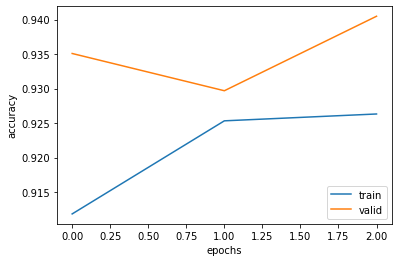

In [12]:
plt.plot(history.history['accuracy'], label = 'train',)
plt.plot(history.history['val_accuracy'], label = 'valid')

plt.legend(loc = 'lower right')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.show()

In [13]:
pred = np.argmax(model.predict(test_generator), axis=1)

In [ ]:
labels = (test_generator.class_indices)

In [ ]:
labels = dict((v,k) for k,v in labels.items())

In [ ]:
pred_label = [labels[k] for k in pred]

In [ ]:
y_test = list(test_df.Label)

In [ ]:
score = accuracy_score(y_test,pred_label)
print(f'Accuracy score: {score * 100}')

Accuracy score: 94.84126984126983


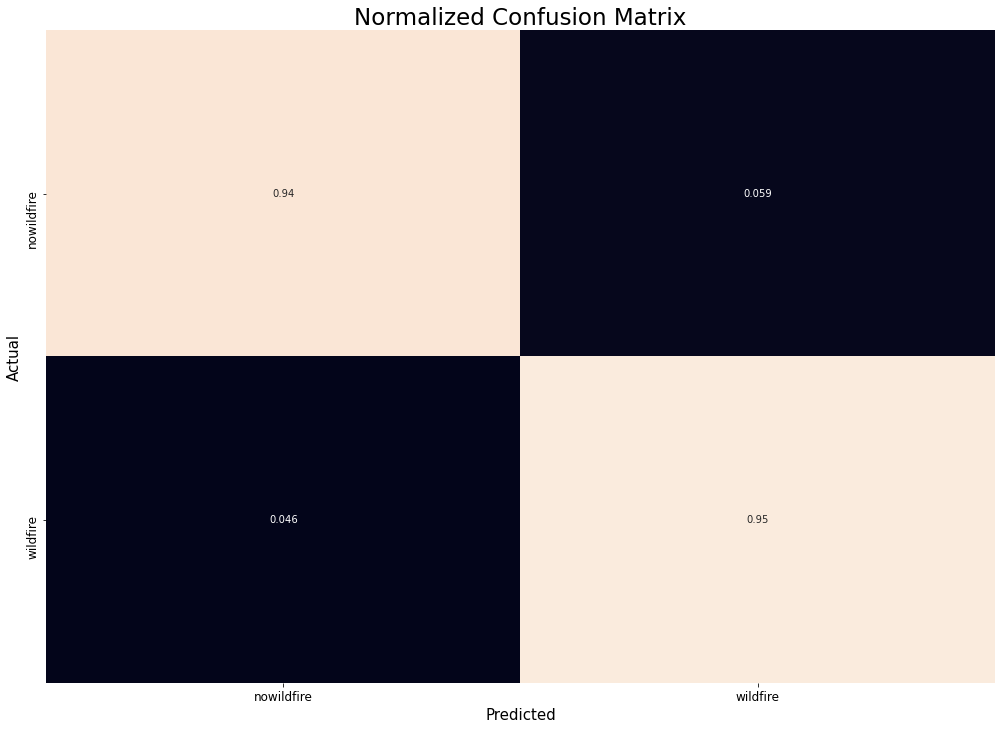

In [14]:
cf_matrix = confusion_matrix(y_test, pred_label, normalize='true')
plt.figure(figsize = (17,12))
sns.heatmap(cf_matrix, annot=True, xticklabels = sorted(set(y_test)), yticklabels = sorted(set(y_test)),cbar=False)
plt.title('Normalized Confusion Matrix', fontsize = 23)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Predicted", fontsize=15)
plt.ylabel("Actual", fontsize=15)
plt.show()

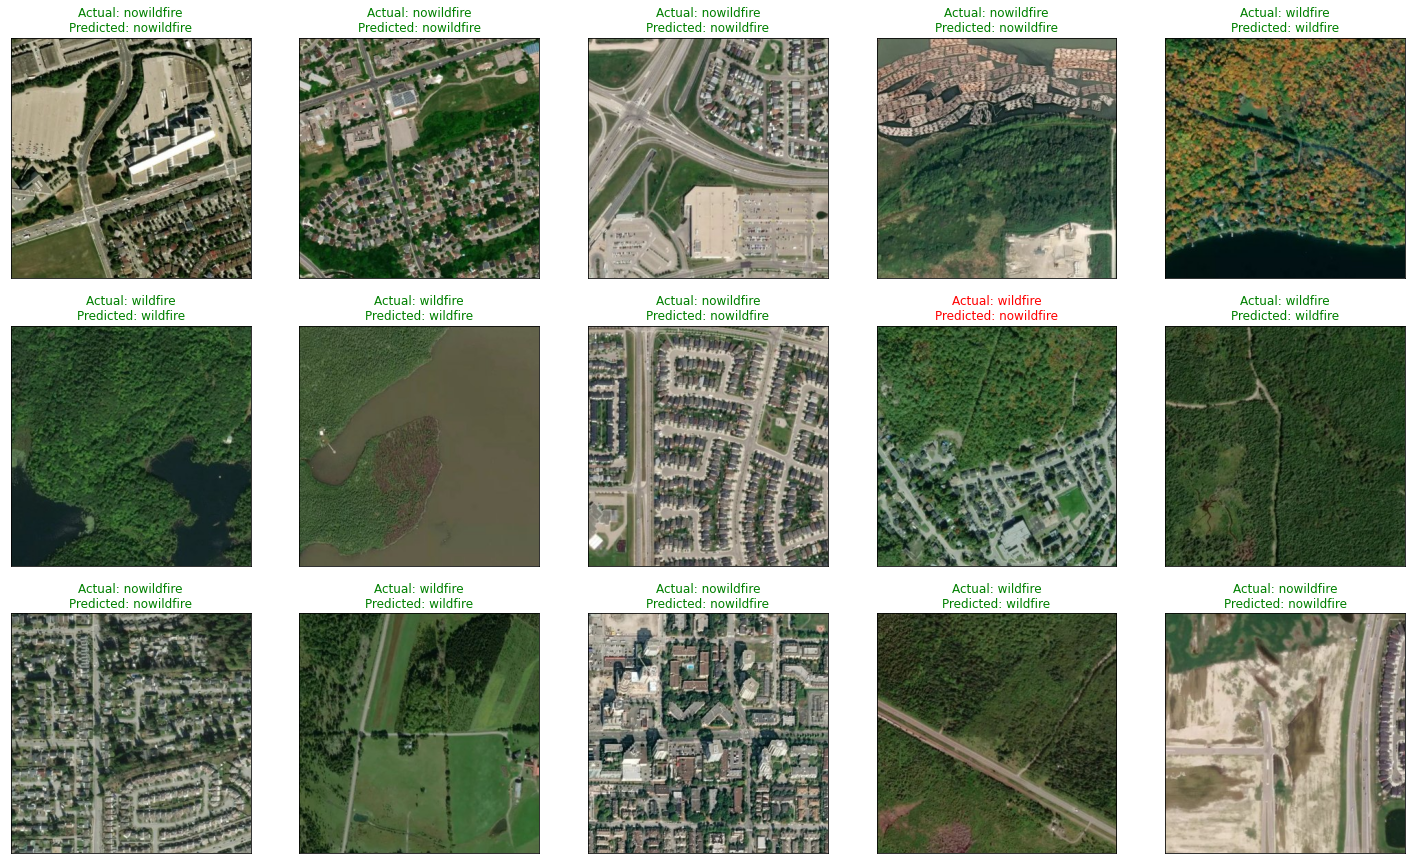

<Figure size 432x288 with 0 Axes>

In [15]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

random_index = np.random.randint(0, len(test_df) - 1, 15)
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_generator.filepaths[random_index[i]]))
    if labels[test_generator.labels[random_index[i]]] == pred_label[random_index[i]]:
      color = "green"
    else:
      color = "red"
    ax.set_title(f"Actual: {labels[test_generator.labels[random_index[i]]]}\nPredicted: {pred_label[random_index[i]]}", color=color)
plt.show()
plt.tight_layout()